# EJERCICIO FINAL PYSPARK (DOCKER + KAFKA + PYSPARK)

In [47]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import *
from pyspark.sql.types import *
from pyspark.sql import functions as F
from pyspark.sql.window import Window


## Creamos la sesión de spark

In [48]:
spark = (
    SparkSession.builder
        .appName("ProyectoIoT")
        .getOrCreate()
)
spark

spark.readStream
Indica que vamos a leer datos en modo streaming, es decir, datos que llegan continuamente.

.format("kafka")
Le decimos a Spark que la fuente de datos de streaming será Kafka.

.option("kafka.bootstrap.servers", "kafka:9092")
Especifica la dirección del clúster Kafka al que conectarse.
En este caso "kafka" es el nombre del contenedor Docker y 9092 es el puerto del broker.

.option("subscribe", "sensores")
Indica el topic de Kafka del que queremos leer mensajes → "sensores".

.option("startingOffsets", "latest")
Define desde qué punto empezar a leer:

"latest" → solo recibe mensajes nuevos, enviados después de iniciar el streaming.

"earliest" sería para leer todos los mensajes antiguos también.

.load()
Ejecuta la configuración y crea un DataFrame de streaming, donde cada fila representa un mensaje recibido desde Kafka.

In [49]:
raw_df = (
    spark.readStream
         .format("kafka")
         .option("kafka.bootstrap.servers", "kafka:9092")  # <-- nombre del contenedor
         .option("subscribe", "sensores")
         .option("startingOffsets", "latest")
         .load()
)


Este bloque transforma los mensajes de Kafka en un formato que Spark puede procesar:

Define la estructura de los datos que esperamos recibir (sensor, valor, temperatura, humedad, estado, timestamp y UUID).

Convierte el JSON recibido en columnas individuales para poder trabajar con cada campo.

Crea una columna de tiempo (event_time) a partir del timestamp original para poder usarlo en ventanas y agregaciones temporales.

In [50]:
schema = StructType([
    StructField("sensor_id", StringType()),
    StructField("value", DoubleType()),
    StructField("temperature", DoubleType()),
    StructField("humidity", DoubleType()),
    StructField("status", StringType()),
    StructField("timestamp", DoubleType()),
    StructField("uuid", StringType())
])

df = raw_df.select(
    from_json(col("value").cast("string"), schema).alias("data")
).select("data.*")

df = df.withColumn("event_time", col("timestamp").cast("timestamp"))


Este bloque realiza agregaciones por ventana de tiempo sobre el DataFrame de streaming:

Define un watermark de 1 minuto para indicar a Spark hasta qué punto los datos antiguos se pueden considerar válidos. Esto ayuda a manejar retrasos y datos tardíos.

Agrupa los datos cada 30 segundos por sensor (sensor_id).

Calcula estadísticas dentro de cada ventana: promedio de valor, temperatura y humedad, y cuenta el número de eventos recibidos.

El resultado es un DataFrame de streaming con resúmenes temporales por sensor listo para análisis o escritura.

In [51]:
agg_df = (
    df
    .withWatermark("event_time", "1 minute")   # ← IMPORTANTE
    .groupBy(
        window(col("event_time"), "30 seconds"),
        col("sensor_id")
    )
    .agg(
        avg("value").alias("avg_value"),
        avg("temperature").alias("avg_temp"),
        avg("humidity").alias("avg_humidity"),
        count("*").alias("num_events")
    )
)


Este bloque escribe los resultados del streaming en archivos Parquet de manera continua:

Define la carpeta de salida donde se guardarán los archivos Parquet (resultados/).

Usa un checkpoint (chk/) para que Spark recuerde qué datos ya procesó y pueda reiniciar de forma segura en caso de fallo.

Modo append: los nuevos datos se agregan continuamente a los archivos existentes.

Inicia el streaming, haciendo que las agregaciones se escriban en tiempo real mientras llegan nuevos datos.

El resultado es un conjunto de archivos Parquet que refleja las métricas agregadas por ventana y por sensor.

In [52]:
parquet_query = (
    agg_df
    .writeStream
    .format("parquet")
    .option("path", "resultados/")
    .option("checkpointLocation", "chk/")
    .outputMode("append")
    .start()
)


A partir de aquí, te toca a ti, sigue las cuestiones planteadas en el Readme y completa el notebook. Despues guardatelo con los outputs de las celdas y súbelo al repo. Mucha suerte que ya lo teneis ;)

In [54]:
### Ejercicio 1:

from pyspark.sql import functions as F

# Mostrar esquema
print("ESQUEMA:")
agg_df.printSchema()

# Cargar datos y contar
df_resultados = spark.read.parquet("resultados/")
total_filas = df_resultados.count()
total_sensores = df_resultados.select("sensor_id").distinct().count()

# Mostrar resultados
print(f"\nEl dataframe tiene {total_filas} filas.")
print(f"Hay un total de {total_sensores} sensores distintos.")




                        


ESQUEMA:
root
 |-- window: struct (nullable = false)
 |    |-- start: timestamp (nullable = true)
 |    |-- end: timestamp (nullable = true)
 |-- sensor_id: string (nullable = true)
 |-- avg_value: double (nullable = true)
 |-- avg_temp: double (nullable = true)
 |-- avg_humidity: double (nullable = true)
 |-- num_events: long (nullable = false)


El dataframe tiene 476 filas.
Hay un total de 4 sensores distintos.


In [55]:
### Ejercicio 2
from pyspark.sql import functions as F

# Crear nueva columna con la diferencia
df_ex2 = df_resultados.withColumn(
    "rango_metrica",
    F.col("avg_value") - F.col("avg_temp")
)

# Calcular estadísticas
stats = df_ex2.select(
    F.min("rango_metrica").alias("minimo"),
    F.max("rango_metrica").alias("maximo"),
    F.avg("rango_metrica").alias("media")
).first()

print("TRANSFORMACIONES NUMÉRICAS")
print(f"Valor mínimo: {stats.minimo:.4f}")
print(f"Valor máximo: {stats.maximo:.4f}")
print(f"Valor medio: {stats.media:.4f}")


TRANSFORMACIONES NUMÉRICAS
Valor mínimo: -51.0733
Valor máximo: 2.3775
Valor medio: -25.4355


In [45]:
### Ejercicio 3

from pyspark.sql import functions as F

df_filtrado = df_resultados.filter(
    (F.col("avg_humidity") > 50) &
    (F.col("num_events") >= 3) &
    (F.col("sensor_id").startswith("sensor_"))
)

num_filtrados = df_filtrado.count()
print(f"Registros que cumplen las condiciones: {num_filtrados}")

df_filtrado.show(10)

Registros que cumplen las condiciones: 0
+------+---------+---------+--------+------------+----------+
|window|sensor_id|avg_value|avg_temp|avg_humidity|num_events|
+------+---------+---------+--------+------------+----------+
+------+---------+---------+--------+------------+----------+



In [56]:
### Ejercicio 4
from pyspark.sql import functions as F

# Agrupar por sensor y calcular estadísticas
df_agg_sensor = df_resultados.groupBy("sensor_id").agg(
    F.avg("avg_value").alias("media_value"),
    F.max("avg_temp").alias("temp_maxima"),
    F.count("*").alias("num_ventanas")
).orderBy(F.desc("media_value"))

print("ESTADÍSTICAS POR SENSOR:")
df_agg_sensor.show()

# Sensor con mayor media
mejor_sensor = df_agg_sensor.first()
print(f"\nSensor con mayor media: {mejor_sensor.sensor_id} ({mejor_sensor.media_value:.2f})")

# Sensor con temperatura máxima
sensor_temp_max = df_resultados.orderBy(F.desc("avg_temp")).first()
print(f"Sensor con temperatura máxima: {sensor_temp_max.sensor_id} ({sensor_temp_max.avg_temp:.2f}°C)")

# Ventanas por sensor
print("\nNúmero de ventanas por sensor:")
df_agg_sensor.select("sensor_id", "num_ventanas").show()

ESTADÍSTICAS POR SENSOR:
+---------+------------------+-----------+------------+
|sensor_id|       media_value|temp_maxima|num_ventanas|
+---------+------------------+-----------+------------+
|       S4| 30.16447947393684|      77.36|         119|
|       S1|30.025066438929883|      74.99|         119|
|       S3| 29.87005969741524|     71.914|         119|
|       S2|29.665502003831833|     84.435|         119|
+---------+------------------+-----------+------------+


Sensor con mayor media: S4 (30.16)
Sensor con temperatura máxima: S2 (84.44°C)

Número de ventanas por sensor:
+---------+------------+
|sensor_id|num_ventanas|
+---------+------------+
|       S4|         119|
|       S1|         119|
|       S3|         119|
|       S2|         119|
+---------+------------+



In [58]:
### Ejercicio 5
from pyspark.sql import functions as F
from pyspark.sql.window import Window

# Definir ventana: particionar por sensor, ordenar por avg_value descendente
ventana = Window.partitionBy("sensor_id").orderBy(F.desc("avg_value"))

# Añadir ranking
df_rank = df_resultados.withColumn("ranking", F.row_number().over(ventana))

# Obtener el mejor registro de cada sensor (rank = 1)
df_top = df_rank.filter(F.col("ranking") == 1)

print("MEJOR avg_value POR SENSOR:")
df_top.select("sensor_id", "avg_value").show()

# Sensor con el máximo global
max_global = df_top.orderBy(F.desc("avg_value")).first()
print(f"\nSensor con valor máximo global: {max_global.sensor_id}")
print(f"Valor: {max_global.avg_value:.2f}")

MEJOR avg_value POR SENSOR:
+---------+------------------+
|sensor_id|         avg_value|
+---------+------------------+
|       S1|40.809999999999995|
|       S2| 40.82285714285714|
|       S3|            40.816|
|       S4|            43.676|
+---------+------------------+


Sensor con valor máximo global: S4
Valor: 43.68


In [59]:
### Ejercicio 6

# Crear DataFrame auxiliar
datos_auxiliares = [
    ("sensor_1", "Exterior", "Tipo A"),
    ("sensor_2", "Interior", "Tipo B"),
    ("sensor_3", "Exterior", "Tipo A"),
    ("sensor_4", "Interior", "Tipo C")
]

df_aux = spark.createDataFrame(datos_auxiliares, ["sensor_id", "ubicacion", "tipo"])

# Hacer join
df_joined = df_resultados.join(df_aux, on="sensor_id", how="left")

# Mostrar primeros 5 registros
df_joined.show(5)

+---------+--------------------+------------------+------------------+------------------+----------+---------+----+
|sensor_id|              window|         avg_value|          avg_temp|      avg_humidity|num_events|ubicacion|tipo|
+---------+--------------------+------------------+------------------+------------------+----------+---------+----+
|       S4|{2026-02-04 15:51...|            25.744| 51.25599999999999|            48.102|         5|     NULL|NULL|
|       S4|{2026-02-04 16:14...|30.903333333333332| 63.91555555555556| 50.31222222222222|         9|     NULL|NULL|
|       S4|{2026-02-04 16:15...|             28.07|            59.625|             55.09|         8|     NULL|NULL|
|       S3|{2026-02-04 16:14...|31.731666666666666| 46.86833333333333|61.500833333333325|        12|     NULL|NULL|
|       S1|{2026-02-04 15:51...| 32.24090909090909|47.472727272727276|52.223636363636366|        11|     NULL|NULL|
+---------+--------------------+------------------+------------------+--

In [60]:
### Ejercicio 7

from pyspark.sql import functions as F

# Extraer inicio de ventana y truncar a minutos
df_temporal = df_resultados.withColumn("inicio_ventana", F.col("window.start"))
df_temporal = df_temporal.withColumn("minuto", F.date_trunc("minute", F.col("inicio_ventana")))

# Agrupar por minuto
df_por_minuto = df_temporal.groupBy("minuto").agg(
    F.count("*").alias("num_ventanas"),
    F.avg("avg_humidity").alias("humedad_media")
).orderBy("minuto")

df_por_minuto.show()

+-------------------+------------+------------------+
|             minuto|num_ventanas|     humedad_media|
+-------------------+------------+------------------+
|2026-02-04 15:40:00|           8| 53.02146428571429|
|2026-02-04 15:41:00|           8| 52.41919990079364|
|2026-02-04 15:42:00|           8|50.998013306138304|
|2026-02-04 15:43:00|           8|57.728615259740266|
|2026-02-04 15:44:00|           8| 56.91297637085137|
|2026-02-04 15:45:00|           8|55.386924242424236|
|2026-02-04 15:46:00|           8| 47.19668353174603|
|2026-02-04 15:47:00|           8|58.011866071428564|
|2026-02-04 15:48:00|           8| 58.02234577922078|
|2026-02-04 15:49:00|           8| 54.05934077380953|
|2026-02-04 15:50:00|           8| 53.59083085317461|
|2026-02-04 15:51:00|           8| 53.75407656926407|
|2026-02-04 15:52:00|           8|54.245785308441555|
|2026-02-04 15:53:00|           8|53.777968434343435|
|2026-02-04 15:54:00|           8|53.760530753968254|
|2026-02-04 15:55:00|       

In [61]:
### Ejercicio 8
from pyspark.sql import functions as F

# Reparticionar por sensor_id
df_repart = df_resultados.repartition(4, "sensor_id")

# Añadir columna con ID de partición
df_con_particion = df_repart.withColumn("partition_id", F.spark_partition_id())

# Distribución de registros por partición
distribucion = df_con_particion.groupBy("partition_id").count().orderBy("partition_id")

distribucion.show()

+------------+-----+
|partition_id|count|
+------------+-----+
|           0|  119|
|           1|  238|
|           3|  119|
+------------+-----+



In [62]:
### Ejercicio 9
from pyspark.sql import functions as F

# Calcular estadísticas globales
estadisticas = df_resultados.select(
    F.mean("avg_temp").alias("temp_media"),
    F.stddev("avg_temp").alias("temp_std"),
    F.mean("avg_value").alias("value_media"),
    F.stddev("avg_value").alias("value_std")
).first()

# Definir anomalías (más de 2 desviaciones estándar)
df_anomalias = df_resultados.withColumn(
    "es_anomalia",
    (F.abs(F.col("avg_temp") - estadisticas.temp_media) > 2 * estadisticas.temp_std) |
    (F.abs(F.col("avg_value") - estadisticas.value_media) > 2 * estadisticas.value_std)
)

# Contar anomalías
total_anomalias = df_anomalias.filter(F.col("es_anomalia")).count()
print(f"Registros anómalos: {total_anomalias}")

# Sensor con más anomalías
sensor_anomalo = df_anomalias.filter(F.col("es_anomalia")).groupBy("sensor_id").count().orderBy(F.desc("count")).first()
print(f"Sensor con más anomalías: {sensor_anomalo.sensor_id} ({sensor_anomalo['count']} anomalías)")

Registros anómalos: 48
Sensor con más anomalías: S4 (13 anomalías)


In [63]:
### Ejercicio 10

from pyspark.sql import functions as F

# Crear puntuación combinada
df_score = df_resultados.withColumn(
    "puntuacion",
    (F.col("avg_value") * 0.4) + 
    (F.col("avg_temp") * 0.3) + 
    (F.col("avg_humidity") * 0.3)
)

# Encontrar sensor con mejor puntuación
mejor_score = df_score.groupBy("sensor_id").agg(
    F.max("puntuacion").alias("puntuacion_maxima")
).orderBy(F.desc("puntuacion_maxima")).first()

print(f"Sensor con puntuación más alta: {mejor_score.sensor_id}")
print(f"Puntuación: {mejor_score.puntuacion_maxima:.2f}")

Sensor con puntuación más alta: S4
Puntuación: 57.08


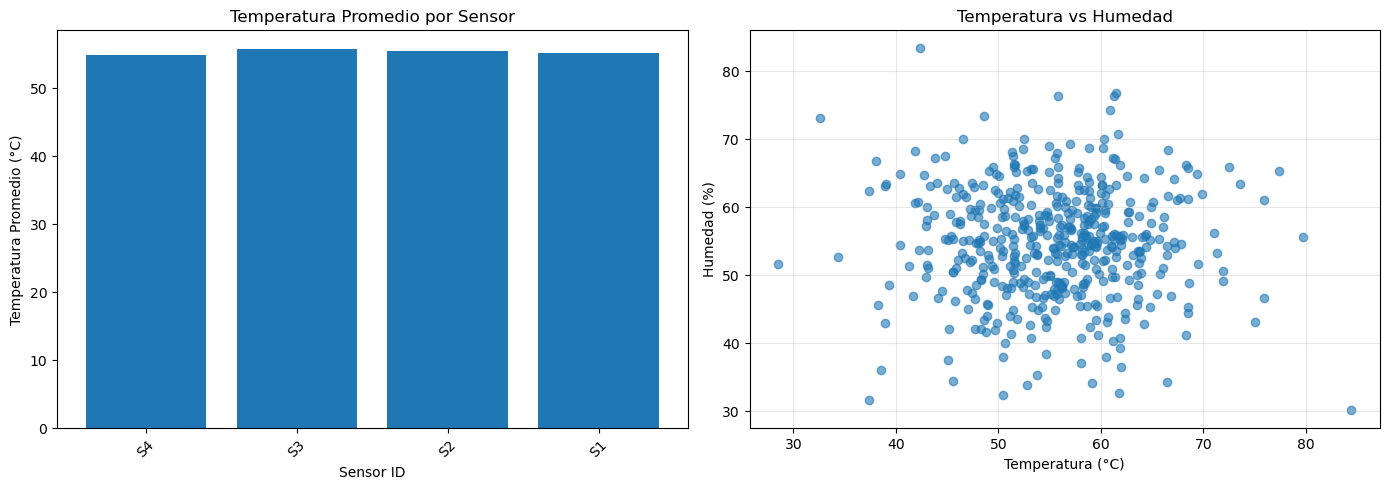

In [64]:
### Ejercicio 11
import matplotlib.pyplot as plt

# Convertir a Pandas
df_pandas = df_resultados.limit(500).toPandas()

# Crear figura con 2 subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Temperatura promedio por sensor
temp_por_sensor = df_resultados.groupBy("sensor_id").agg(
    F.avg("avg_temp").alias("temp_promedio")
).toPandas()

ax1.bar(temp_por_sensor['sensor_id'], temp_por_sensor['temp_promedio'])
ax1.set_xlabel('Sensor ID')
ax1.set_ylabel('Temperatura Promedio (°C)')
ax1.set_title('Temperatura Promedio por Sensor')
ax1.tick_params(axis='x', rotation=45)

# Gráfico 2: Scatter plot Temperatura vs Humedad
ax2.scatter(df_pandas['avg_temp'], df_pandas['avg_humidity'], alpha=0.6)
ax2.set_xlabel('Temperatura (°C)')
ax2.set_ylabel('Humedad (%)')
ax2.set_title('Temperatura vs Humedad')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()